# Online ET-DHP B-747 engine-out experiment with one four-channel controller

This notebook keeps the controller architecture close to the event-triggered DHP setup: one `ETDHPAgent` receives an augmented regulation state and outputs all four B-747 virtual controls

\[
 u = [\delta_e, \delta_a, \delta_r, \delta_T].
\]

The closed-loop path has no PID, no LQR controller, and no trajectory-imitation dataset. The runtime loop is

```python
agent.predict(obs, agent_reference, k)
env.step(compose_action(agent.last_action()))
agent.learn(next_obs, next_reference, k, dt=DT)
```

The engine-loss feature is included in the ET-DHP state because the shipped ET-DHP actor/critic networks have no bias terms. Without an explicit failure feature, a zero-error post-failure input would mathematically force the actor output to zero and it could not hold the required asymmetric trim.


## 1. Imports and simulation settings


In [1]:
import warnings
warnings.filterwarnings("ignore")

import copy
import math

import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

from tensoraerospace.aerospacemodel.b747.nonlinear import B747Configuration, trim
from tensoraerospace.aerospacemodel.b747.nonlinear.damage.state import B747DamageState
from tensoraerospace.aerospacemodel.b747.nonlinear.dynamics import b747_ode_6dof
from tensoraerospace.aerospacemodel.b747.nonlinear.engine import JT9DEngine
from tensoraerospace.aerospacemodel.b747.nonlinear.params import (
    default_parameters, isa_speed_of_sound_ft_s,
)
from tensoraerospace.aerospacemodel.b747.nonlinear.damage import LEFT_OUTER_ENGINE_FAILURE
from tensoraerospace.envs.b747_nonlinear import NonlinearB747Env
from tensoraerospace.agent.et_dhp import ETDHPAgent, ETDHPConfig

DT = 0.05
TOTAL_TIME = 300.0
TRAIN_TIME = TOTAL_TIME
DAMAGE_TIME = 10.0
N_EP = int(TOTAL_TIME / DT)
N_TRAIN = int(TRAIN_TIME / DT)
DAMAGE_STEP = int(DAMAGE_TIME / DT)

V_REF_FT_S = 674.0
ALT_REF_FT = 20_000.0
PSI_REF_DEG = 0.0

# Final-window acceptance bands for the ET-DHP-only closed loop.
SPEED_HOLD_BAND_FT_S = 1.0
ALT_HOLD_BAND_FT = 1.5
YAW_HOLD_BAND_DEG = 0.05
ROLL_HOLD_BAND_DEG = 0.12
PITCH_HOLD_BAND_DEG = 0.05

# ET-DHP actuator residual bounds around the healthy trim point. The
# actor outputs normalized values in [-1, 1]^4; compose_action maps them.
ELEVATOR_RESIDUAL_BOUND_DEG = 6.0
AILERON_BOUND_DEG = 8.0
RUDDER_BOUND_DEG = 8.0
THROTTLE_RESIDUAL_BOUND = 0.35

# Integral limits. Yaw/roll integrals are stored in deg*s in the notebook
# helpers and converted to rad*s inside the ET-DHP state vector.
I_V_LIMIT_FT = 1_000.0
I_H_LIMIT_FT_S = 30_000.0
I_LAT_LIMIT_DEG_S = 60.0

print(f"Evaluation length: {TOTAL_TIME:.0f} s ({N_EP} steps @ dt={DT}s)")
print(f"ET-DHP training horizon shown in plots: {TRAIN_TIME:.0f} s ({N_TRAIN} steps)")
print(f"Damage trigger: t = {DAMAGE_TIME:.0f} s (step {DAMAGE_STEP})")
print("Final-window tolerances:")
print(f"  RMSE |V - V0| <= {SPEED_HOLD_BAND_FT_S:.1f} ft/s")
print(f"  RMSE |h - h0| <= {ALT_HOLD_BAND_FT:.1f} ft")
print(f"  RMSE |psi| <= {YAW_HOLD_BAND_DEG:.2f} deg, "
      f"|phi| <= {ROLL_HOLD_BAND_DEG:.2f} deg, "
      f"|theta-theta0| <= {PITCH_HOLD_BAND_DEG:.2f} deg")


Evaluation length: 300 s (6000 steps @ dt=0.05s)
ET-DHP training horizon shown in plots: 300 s (6000 steps)
Damage trigger: t = 10 s (step 200)
Final-window tolerances:
  RMSE |V - V0| <= 1.0 ft/s
  RMSE |h - h0| <= 1.5 ft
  RMSE |psi| <= 0.05 deg, |phi| <= 0.12 deg, |theta-theta0| <= 0.05 deg


## 2. Cruise trim point

The plant starts from a healthy four-engine cruise trim at FL200 and $V \approx 674$ ft/s. Elevator trim and throttle trim are used only as fixed actuator biases. The single ET-DHP actor supplies all four residual commands: elevator, aileron, rudder and throttle.


In [2]:
trim_result = trim(altitude_ft=ALT_REF_FT, V_ft_s=V_REF_FT_S,
                   config=B747Configuration.NOMINAL)
assert trim_result.converged

healthy_trim_state = trim_result.to_state()
delta_e_trim_rad = float(trim_result.elevator_rad)
throttle_trim = float(trim_result.throttle)
theta_ref_deg = math.degrees(trim_result.theta_rad)
throttle_engine_out_estimate = min(throttle_trim * 4.0 / 3.0, 1.0)
engine_params = default_parameters(B747Configuration.NOMINAL)
engine_model = JT9DEngine(
    n_engines=4,
    sls_thrust_per_engine_lb=engine_params.engine_thrust_max_lb / 4.0,
    idle_frac=engine_params.engine_idle_frac,
    spool_tau_s=engine_params.engine_tau_s,
)

# Static post-failure trim used only for the ET-DHP state origin and
# local plant-model calculation. The final controller still sends the
# actor output directly; compose_action does not inject this trim.
engine_out_params = default_parameters(B747Configuration.NOMINAL)
engine_out_damage_state = B747DamageState.healthy()
engine_out_damage_state.engines_mu[1] = 0.0
engine_out_params.damage_state = engine_out_damage_state


def engine_out_state_from_vars(alpha_rad, beta_rad, theta_rad):
    return np.array([
        V_REF_FT_S * math.cos(alpha_rad) * math.cos(beta_rad),
        V_REF_FT_S * math.sin(beta_rad),
        V_REF_FT_S * math.sin(alpha_rad) * math.cos(beta_rad),
        0.0, 0.0, 0.0,
        0.0, theta_rad, 0.0,
        0.0, 0.0, -ALT_REF_FT,
    ], dtype=np.float64)


def engine_out_trim_residual(z):
    alpha_rad, beta_rad, theta_rad, de_rad, da_rad, dr_rad, throttle = z
    x = engine_out_state_from_vars(alpha_rad, beta_rad, theta_rad)
    u = np.array([de_rad, da_rad, dr_rad, np.clip(throttle, 0.0, 1.0)], dtype=np.float64)
    dx = b747_ode_6dof(x, u, 0.0, engine_out_params)
    return np.array([dx[0], dx[1], dx[2], dx[3], dx[4], dx[5], dx[11]], dtype=np.float64)


z0 = np.array([
    trim_result.alpha_rad,
    math.radians(-0.44),
    trim_result.theta_rad,
    delta_e_trim_rad,
    math.radians(-4.4),
    math.radians(-2.64),
    throttle_engine_out_estimate,
], dtype=np.float64)
engine_out_solution, info, ier, msg = fsolve(
    engine_out_trim_residual, z0, full_output=True, xtol=1e-10, maxfev=2_000
)
engine_out_residual_norm = float(np.linalg.norm(info["fvec"]))
assert ier == 1 and engine_out_residual_norm < 1e-6, msg

(
    alpha_engine_out_rad,
    beta_engine_out_rad,
    theta_engine_out_rad,
    delta_e_engine_out_rad,
    delta_a_engine_out_rad,
    delta_r_engine_out_rad,
    throttle_engine_out,
) = engine_out_solution
throttle_engine_out = float(np.clip(throttle_engine_out, 0.0, 1.0))
engine_out_trim_state = engine_out_state_from_vars(
    alpha_engine_out_rad, beta_engine_out_rad, theta_engine_out_rad
)
engine_out_trim_action = np.array([
    delta_e_engine_out_rad,
    delta_a_engine_out_rad,
    delta_r_engine_out_rad,
    throttle_engine_out,
], dtype=np.float64)
engine_out_action_norm = np.array([
    (delta_e_engine_out_rad - delta_e_trim_rad) / math.radians(ELEVATOR_RESIDUAL_BOUND_DEG),
    math.degrees(delta_a_engine_out_rad) / AILERON_BOUND_DEG,
    math.degrees(delta_r_engine_out_rad) / RUDDER_BOUND_DEG,
    (throttle_engine_out - throttle_trim) / THROTTLE_RESIDUAL_BOUND,
], dtype=np.float64)

print(f"Trim @ FL200, V={V_REF_FT_S:.0f} ft/s, NOMINAL:")
print(f"  alpha = theta = {theta_ref_deg:+.3f} deg")
print(f"  delta_e_trim  = {math.degrees(delta_e_trim_rad):+.3f} deg")
print(f"  throttle_trim = {throttle_trim:.4f}")
print(f"  one-engine-out throttle estimate = {throttle_engine_out_estimate:.4f} (context only)")
print("Static one-engine-out equilibrium used by ET-DHP state/model:")
print(f"  beta = {math.degrees(beta_engine_out_rad):+.3f} deg")
print(f"  de/da/dr/throttle = {math.degrees(delta_e_engine_out_rad):+.3f} deg, "
      f"{math.degrees(delta_a_engine_out_rad):+.3f} deg, "
      f"{math.degrees(delta_r_engine_out_rad):+.3f} deg, {throttle_engine_out:.4f}")
print(f"  normalized ET-DHP equilibrium action = {engine_out_action_norm}")


Trim @ FL200, V=674 ft/s, NOMINAL:
  alpha = theta = +3.603 deg
  delta_e_trim  = -0.722 deg
  throttle_trim = 0.5549
  one-engine-out throttle estimate = 0.7399 (context only)
Static one-engine-out equilibrium used by ET-DHP state/model:
  beta = -0.440 deg
  de/da/dr/throttle = -0.722 deg, -4.403 deg, -2.642 deg, 0.7575
  normalized ET-DHP equilibrium action = [-3.31307779e-17 -5.50387641e-01 -3.30284006e-01  5.78632871e-01]


## 3. State transform and command composition

The unified ET-DHP state is

$$
\tilde x=\left[
\frac{e_V}{25},\frac{i_V}{500},
\frac{e_h}{250},\frac{i_h}{15000},
\frac{e_\theta}{3},\frac{q}{3},
\frac{e_\psi}{8},\frac{i_\psi}{30},
\frac{r}{5},\frac{\phi}{8},\frac{i_\phi}{30},\frac{p}{5}
\right]^T.
$$

The actor output is

$$
u=[u_e,u_a,u_r,u_T]^T \in [-1,1]^4,
$$

and `compose_action()` maps it to physical B-747 commands around the healthy trim. This keeps the ET-DHP output units homogeneous even though the plant uses radians and throttle.


In [3]:
def wrap_deg(angle_deg):
    """Wrap an angle to [-180, 180) deg."""
    return (float(angle_deg) + 180.0) % 360.0 - 180.0


def wrap_rad(angle_rad):
    """Wrap an angle to [-pi, pi) rad."""
    return (float(angle_rad) + math.pi) % (2.0 * math.pi) - math.pi


def true_airspeed_ft_s(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return float(np.linalg.norm(obs[:3]))


def altitude_ft(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return float(-obs[11])


def yaw_error_deg(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return wrap_deg(math.degrees(obs[8]) - PSI_REF_DEG)


def roll_deg(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return math.degrees(obs[6])


def pitch_error_deg(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return math.degrees(obs[7]) - theta_ref_deg


def update_etdhp_integrals(integrals, obs):
    """Update [int V, int h, int psi, int phi] with clipping."""
    errors = np.array([
        true_airspeed_ft_s(obs) - V_REF_FT_S,
        altitude_ft(obs) - ALT_REF_FT,
        yaw_error_deg(obs),
        roll_deg(obs),
    ], dtype=np.float64)
    next_integrals = np.asarray(integrals, dtype=np.float64) + errors * DT
    return np.clip(
        next_integrals,
        [-I_V_LIMIT_FT, -I_H_LIMIT_FT_S, -I_LAT_LIMIT_DEG_S, -I_LAT_LIMIT_DEG_S],
        [I_V_LIMIT_FT, I_H_LIMIT_FT_S, I_LAT_LIMIT_DEG_S, I_LAT_LIMIT_DEG_S],
    )


# Full augmented ET-DHP state scaling. The first 12 entries are the raw
# B-747 state error; the next four are integral errors; the final entry
# is the engine-loss feature. x_e/y_e are included with zero cost so the
# local model remains consistent with the 6-DoF state layout.
AUG_STATE_SCALE = np.array([
    25.0, 25.0, 25.0,
    math.radians(5.0), math.radians(3.0), math.radians(5.0),
    math.radians(8.0), math.radians(3.0), math.radians(8.0),
    1_000.0, 1_000.0, 250.0,
    500.0, 15_000.0, 1.0, 1.0,
], dtype=np.float64)
N_ETDHP_STATE = int(AUG_STATE_SCALE.size + 1)


def agent_reference(integrals, engine_loss):
    """Pack ET-DHP integral states and the engine-loss estimate."""
    return np.r_[np.asarray(integrals, dtype=np.float64).reshape(4), float(engine_loss)]


def reference_trim_state(engine_loss):
    engine_loss = float(np.clip(engine_loss, 0.0, 1.0))
    return (1.0 - engine_loss) * healthy_trim_state + engine_loss * engine_out_trim_state


def unified_state_transform(obs, ref, time_step):
    """Build the 17-state augmented regulation vector for ET-DHP."""
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    packed_ref = np.zeros(5, dtype=np.float64) if ref is None else np.asarray(ref, dtype=np.float64).reshape(-1)
    integrals = np.zeros(4, dtype=np.float64)
    integrals[:min(4, packed_ref.size)] = packed_ref[:min(4, packed_ref.size)]
    engine_loss = float(packed_ref[4]) if packed_ref.size >= 5 else 0.0

    error_state = obs - reference_trim_state(engine_loss)
    error_state[8] = wrap_rad(error_state[8])
    augmented = np.r_[
        error_state,
        integrals[0],
        integrals[1],
        math.radians(integrals[2]),
        math.radians(integrals[3]),
    ]
    return np.r_[augmented / AUG_STATE_SCALE, engine_loss].astype(np.float64)


def make_env(damage_profile=None, n_steps=N_EP + 5):
    return NonlinearB747Env(
        trim_at=(ALT_REF_FT, V_REF_FT_S),
        number_time_steps=n_steps,
        dt=DT,
        integrator="rk4",
        action_space="virtual",
        config=B747Configuration.NOMINAL,
        damage_profile=damage_profile,
    )


def decode_etdhp_action(action_norm):
    """Map normalized ET-DHP action to physical B-747 commands."""
    action_norm = np.asarray(action_norm, dtype=np.float64).reshape(-1)
    if action_norm.size != 4:
        raise ValueError(f"action_norm must have 4 elements, got {action_norm.size}")
    ue, ua, ur, uT = np.clip(action_norm, -1.0, 1.0)

    de_delta_deg = ELEVATOR_RESIDUAL_BOUND_DEG * float(ue)
    da_deg = AILERON_BOUND_DEG * float(ua)
    dr_deg = RUDDER_BOUND_DEG * float(ur)
    throttle_delta = THROTTLE_RESIDUAL_BOUND * float(uT)

    elevator_rad = float(np.clip(
        delta_e_trim_rad + math.radians(de_delta_deg),
        -math.radians(25.0),
        math.radians(25.0),
    ))
    throttle = float(np.clip(throttle_trim + throttle_delta, 0.0, 1.0))
    return elevator_rad, da_deg, dr_deg, throttle


def compose_action(action_norm):
    """Compose [de, da, dr, throttle] for the B-747 env from ET-DHP output."""
    elevator_rad, da_deg, dr_deg, throttle = decode_etdhp_action(action_norm)
    return np.array([
        elevator_rad,
        math.radians(da_deg),
        math.radians(dr_deg),
        throttle,
    ], dtype=np.float64)


def engine_mu_from_info(info):
    """Extract engine effectiveness multipliers from env.step info."""
    damage_state = info.get("damage_state", {}) if isinstance(info, dict) else {}
    engines_mu = damage_state.get("engines_mu", {}) if isinstance(damage_state, dict) else {}
    return {
        engine_id: float(engines_mu.get(engine_id, engines_mu.get(str(engine_id), 1.0)))
        for engine_id in (1, 2, 3, 4)
    }


def per_engine_thrust_lb(obs, throttle, engines_mu):
    """Return effective [T1, T2, T3, T4] thrust in pounds-force."""
    h_ft = altitude_ft(obs)
    mach = true_airspeed_ft_s(obs) / isa_speed_of_sound_ft_s(h_ft)
    cluster_thrust = engine_model.installed_thrust(
        mach=mach,
        altitude_ft=h_ft,
        throttle=throttle,
    )
    per_engine_nominal = cluster_thrust / 4.0
    return np.array([
        per_engine_nominal * float(engines_mu.get(engine_id, 1.0))
        for engine_id in (1, 2, 3, 4)
    ], dtype=np.float64)


## 4. Plant-model identification

ET-DHP needs a differentiable one-step plant model for the DHP Jacobians. This cell collects persistent-excitation transitions on the nonlinear B-747 model, with both healthy and post-failure bursts. The post-failure bursts are centered around the computed engine-out trim only to keep the data local enough for the neural plant model; the final controller still receives only the actor output.


In [4]:
N_BURST = DAMAGE_STEP + 160
N_BURSTS = 48
PE_NOISE_STD = 0.05

rng = np.random.default_rng(0)
states_buf, actions_buf, next_states_buf = [], [], []
num_damaged_bursts = 0

for burst in range(N_BURSTS):
    damage_profile = LEFT_OUTER_ENGINE_FAILURE if burst % 2 else None
    damaged_burst = damage_profile is not None
    num_damaged_bursts += int(damaged_burst)

    env_id = make_env(damage_profile=damage_profile, n_steps=N_BURST + 5)
    obs, _ = env_id.reset()
    integrals = np.zeros(4, dtype=np.float64)

    freqs = np.array([
        0.08 + rng.random() * 0.25,
        0.15 + rng.random() * 0.45,
        0.15 + rng.random() * 0.45,
        0.06 + rng.random() * 0.20,
    ])
    phases = rng.random(4) * 2.0 * np.pi

    for k in range(N_BURST):
        engine_loss = 1.0 if damaged_burst and k >= DAMAGE_STEP else 0.0
        center = engine_out_action_norm if engine_loss else np.zeros(4, dtype=np.float64)
        amplitude = (
            np.array([0.25, 0.25, 0.25, 0.18], dtype=np.float64)
            if engine_loss else np.array([0.25, 0.25, 0.25, 0.25], dtype=np.float64)
        )
        t_sec = k * DT
        action_norm = center + amplitude * np.sin(2.0 * np.pi * freqs * t_sec + phases)
        action_norm += PE_NOISE_STD * rng.normal(size=4)
        action_norm = np.clip(action_norm, -1.0, 1.0)

        x = unified_state_transform(obs, agent_reference(integrals, engine_loss), k)
        obs, _, _, trunc, _ = env_id.step(compose_action(action_norm))
        integrals = update_etdhp_integrals(integrals, obs)
        next_engine_loss = 1.0 if damaged_burst and (k + 1) >= DAMAGE_STEP else 0.0
        x_next = unified_state_transform(
            obs, agent_reference(integrals, next_engine_loss), k + 1
        )

        if np.all(np.isfinite(x_next)) and np.max(np.abs(x_next[:-1])) < 10.0:
            states_buf.append(x)
            actions_buf.append(action_norm)
            next_states_buf.append(x_next)
        if trunc:
            break

states_arr = np.asarray(states_buf, dtype=np.float32)
actions_arr = np.asarray(actions_buf, dtype=np.float32)
next_states_arr = np.asarray(next_states_buf, dtype=np.float32)

print(f"collected {len(states_arr)} transitions")
print(f"healthy bursts: {N_BURSTS - num_damaged_bursts}, engine-out bursts: {num_damaged_bursts}")
print(f"post-failure samples: {int(np.sum(states_arr[:, -1] > 0.5))}")
print(f"state max |x| excluding loss feature: {np.max(np.abs(states_arr[:, :-1])):.3f}")
print(f"action range per channel:\n  min={np.min(actions_arr, axis=0)}\n  max={np.max(actions_arr, axis=0)}")


collected 14224 transitions
healthy bursts: 24, engine-out bursts: 24
post-failure samples: 2317
state max |x| excluding loss feature: 9.965
action range per channel:
  min=[-0.42181307 -0.9405209  -0.7176051  -0.4100789 ]
  max=[0.4317784 0.4065845 0.4063957 0.8838005]


## 5. Build the online ET-DHP agent

The actor is a single no-bias bounded ET-DHP policy with four outputs. The
`engine_loss` input is used only as an actor state feature, so the no-bias
network can represent the required asymmetric engine-out trim at zero
regulation error. Feedback around that trim is still learned by ET-DHP online.


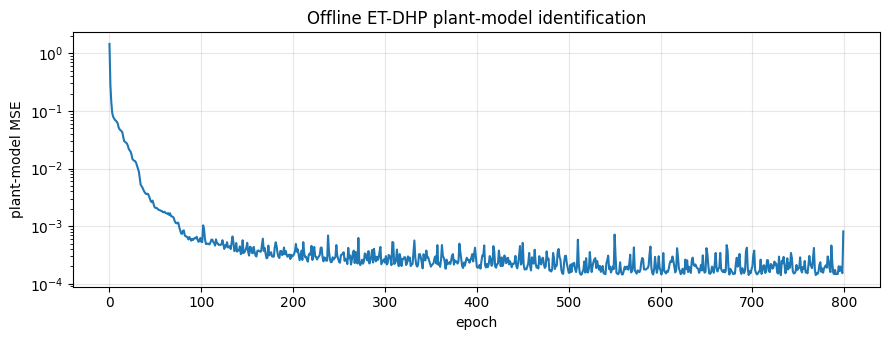

ET-DHP agent: n_state=17, n_control=4
actor/critic optimizer: Adam on ET-DHP actor/critic losses
inner ET-DHP epochs per trigger: 1
final plant-model MSE: 8.126e-04


In [5]:
cfg = ETDHPConfig(
    actor_hidden=(),
    critic_hidden=(48, 48),
    model_hidden=(64, 64),
    actor_lr=5.0e-10,
    critic_lr=1.0e-5,
    model_lr=3.0e-3,
    model_epochs=800,
    Q=[20.0, 5.0, 200.0, 2.0, 5.0, 5.0,
       500.0, 100.0, 800.0, 0.0, 0.0, 30.0,
       10.0, 100.0, 200.0, 200.0, 0.0],
    R=[500.0, 300.0, 80.0, 100.0],
    gamma=0.98,
    num_epochs_per_trigger=1,
    u_bound=1.0,
    rho=0.05,
    trigger_floor=0.03,
    weight_init_scale=1.0e-3,
    seed=23,
)

agent = ETDHPAgent(
    n_state=N_ETDHP_STATE,
    n_control=4,
    state_transform=unified_state_transform,
    config=cfg,
)

# Optimizer tuning only: actor and critic still use the ET-DHP losses in
# agent.learn; there is no teacher policy, Riccati target, or PID loop here.
agent.actor_opt = torch.optim.Adam(agent.actor.parameters(), lr=cfg.actor_lr)
agent.critic_opt = torch.optim.Adam(agent.critic.parameters(), lr=cfg.critic_lr)

# No-bias actor initialization: zero state with engine_loss=1 should command
# the static asymmetric trim. Feedback gains are learned online by ET-DHP.
with torch.no_grad():
    agent.actor.head.weight.zero_()
    agent.actor.head.weight[:, -1] = torch.as_tensor(
        np.arctanh(np.clip(engine_out_action_norm, -0.999, 0.999)),
        dtype=torch.float32,
        device=agent.device,
    )

# DHP critic initialization: immediate quadratic-cost gradient 2Qx. This is
# not Riccati/LQR; it only gives the costate critic the correct local sign
# before online ET-DHP updates start.
with torch.no_grad():
    first_linear = agent.critic.backbone[0]
    first_linear.weight.zero_()
    n_diag = min(first_linear.weight.shape[0], agent.n_state)
    first_linear.weight[:n_diag, :n_diag] = torch.eye(n_diag, device=agent.device)
    agent.critic.head.weight.zero_()
    q_diag = torch.as_tensor(cfg.Q, dtype=torch.float32, device=agent.device)
    agent.critic.head.weight[:n_diag, :n_diag] = torch.diag(2.0 * q_diag[:n_diag])

model_losses = agent.fit_plant_model(
    states_arr, actions_arr, next_states_arr,
    batch_size=512,
    verbose=False,
)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.semilogy(model_losses)
ax.set_xlabel("epoch")
ax.set_ylabel("plant-model MSE")
ax.set_title("Offline ET-DHP plant-model identification")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ET-DHP agent: n_state={agent.n_state}, n_control={agent.n_control}")
print("actor/critic optimizer: Adam on ET-DHP actor/critic losses")
print(f"inner ET-DHP epochs per trigger: {cfg.num_epochs_per_trigger}")
print(f"final plant-model MSE: {model_losses[-1]:.3e}")


## 6. Online ET-DHP training

Training below is the online ET-DHP loop. Every simulation step evaluates the
current actor on the current regulation state, and `agent.learn(...)` runs the
event-triggered actor/critic update only when the trigger fires. No Riccati
policy, LQR gain, PID loop, or offline actor target is used.


ep 1/1: V=   0.060 ft/s  h=    1.16 ft  theta=  0.003 deg  psi=  0.371 deg  phi=  0.032 deg  triggers=119


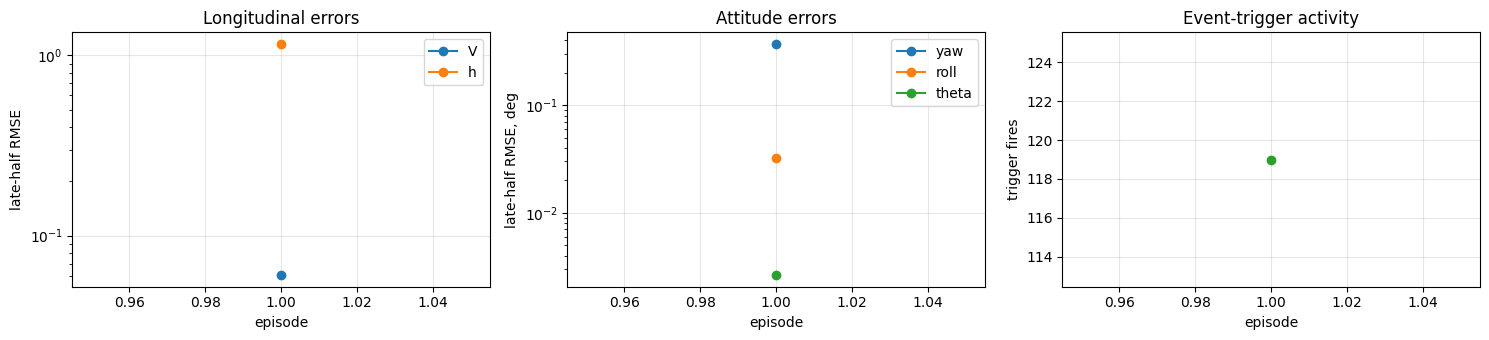

In [6]:
def run_training_episode(damage_profile, *, learn=True, n_steps=N_TRAIN):
    env = make_env(damage_profile=damage_profile, n_steps=n_steps + 5)
    obs, _ = env.reset()
    agent.reset()
    integrals = np.zeros(4, dtype=np.float64)

    logs = {name: np.zeros(n_steps) for name in [
        "V", "h", "theta", "psi", "phi", "de", "da", "dr", "throttle",
    ]}
    triggers = 0
    t_axis = np.arange(n_steps) * DT

    for k in range(n_steps - 2):
        engine_loss = 1.0 if k >= DAMAGE_STEP else 0.0
        agent.predict(obs, agent_reference(integrals, engine_loss), k)
        action_norm = agent.last_action()
        elevator_cmd, da_deg, dr_deg, throttle_cmd = decode_etdhp_action(action_norm)

        obs, _, _, trunc, _ = env.step(compose_action(action_norm))
        integrals = update_etdhp_integrals(integrals, obs)

        if learn:
            next_engine_loss = 1.0 if (k + 1) >= DAMAGE_STEP else 0.0
            metrics = agent.learn(obs, agent_reference(integrals, next_engine_loss), k, dt=DT)
            triggers += int(metrics["triggered"])

        logs["V"][k] = true_airspeed_ft_s(obs) - V_REF_FT_S
        logs["h"][k] = altitude_ft(obs) - ALT_REF_FT
        logs["theta"][k] = pitch_error_deg(obs)
        logs["psi"][k] = yaw_error_deg(obs)
        logs["phi"][k] = roll_deg(obs)
        logs["de"][k] = math.degrees(elevator_cmd)
        logs["da"][k] = da_deg
        logs["dr"][k] = dr_deg
        logs["throttle"][k] = throttle_cmd
        if trunc:
            break

    n = k + 1
    return {name: values[:n] for name, values in logs.items()} | {
        "t": t_axis[:n],
        "triggers": triggers,
    }


NUM_TRAIN_EPISODES = 1
training_curve = []
best_actor_state = copy.deepcopy(agent.actor.state_dict())
best_score = float("inf")

for ep in range(NUM_TRAIN_EPISODES):
    train_log = run_training_episode(LEFT_OUTER_ENGINE_FAILURE, learn=True)
    n2 = len(train_log["V"]) // 2
    row = {
        "ep": ep + 1,
        "speed_rmse": float(np.sqrt(np.mean(train_log["V"][n2:] ** 2))),
        "alt_rmse": float(np.sqrt(np.mean(train_log["h"][n2:] ** 2))),
        "theta_rmse": float(np.sqrt(np.mean(train_log["theta"][n2:] ** 2))),
        "yaw_rmse": float(np.sqrt(np.mean(train_log["psi"][n2:] ** 2))),
        "roll_rmse": float(np.sqrt(np.mean(train_log["phi"][n2:] ** 2))),
        "triggers": train_log["triggers"],
    }
    training_curve.append(row)
    score = (
        row["speed_rmse"] + row["alt_rmse"]
        + 50.0 * row["theta_rmse"]
        + 100.0 * row["yaw_rmse"]
        + 100.0 * row["roll_rmse"]
    )
    if score < best_score:
        best_score = score
        best_actor_state = copy.deepcopy(agent.actor.state_dict())
    print(f"ep {ep + 1}/{NUM_TRAIN_EPISODES}: "
          f"V={row['speed_rmse']:8.3f} ft/s  h={row['alt_rmse']:8.2f} ft  "
          f"theta={row['theta_rmse']:7.3f} deg  psi={row['yaw_rmse']:7.3f} deg  "
          f"phi={row['roll_rmse']:7.3f} deg  triggers={row['triggers']}")

agent.actor.load_state_dict(best_actor_state)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
ep_idx = [r["ep"] for r in training_curve]
axes[0].plot(ep_idx, [r["speed_rmse"] for r in training_curve], "-o", label="V")
axes[0].plot(ep_idx, [r["alt_rmse"] for r in training_curve], "-o", label="h")
axes[0].set_yscale("log")
axes[0].set_xlabel("episode")
axes[0].set_ylabel("late-half RMSE")
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[0].set_title("Longitudinal errors")
axes[1].plot(ep_idx, [r["yaw_rmse"] for r in training_curve], "-o", label="yaw")
axes[1].plot(ep_idx, [r["roll_rmse"] for r in training_curve], "-o", label="roll")
axes[1].plot(ep_idx, [r["theta_rmse"] for r in training_curve], "-o", label="theta")
axes[1].set_yscale("log")
axes[1].set_xlabel("episode")
axes[1].set_ylabel("late-half RMSE, deg")
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[1].set_title("Attitude errors")
axes[2].plot(ep_idx, [r["triggers"] for r in training_curve], "-o", color="tab:green")
axes[2].set_xlabel("episode")
axes[2].set_ylabel("trigger fires")
axes[2].grid(alpha=0.3)
axes[2].set_title("Event-trigger activity")
plt.tight_layout()
plt.show()


## 7. Full closed-loop evaluation

The final run uses the actor after online ET-DHP training. Evaluation keeps
actor/critic weights frozen (`learn=False`) but still evaluates the actor on
each current state, so the plots show whether the trained ET-DHP feedback
actually removes trends in speed, altitude and attitude errors.


In [7]:
def run_full_episode(damage_profile, *, learn=False):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    agent.reset()
    integrals = np.zeros(4, dtype=np.float64)

    logs = {name: np.zeros(N_EP) for name in [
        "V", "h", "theta", "psi", "phi",
        "V_actual", "h_actual", "theta_actual", "psi_actual", "phi_actual",
        "V_ref", "h_ref", "theta_ref", "psi_ref", "phi_ref",
        "p", "q", "r", "de", "da", "dr", "throttle",
        "T1", "T2", "T3", "T4", "T_total",
    ]}
    triggers = 0
    t_axis = np.arange(N_EP) * DT
    info = {}

    for k in range(N_EP - 2):
        engine_loss = 1.0 if k >= DAMAGE_STEP else 0.0
        ref = agent_reference(integrals, engine_loss)
        agent.predict(obs, ref, k)
        action_norm = agent.last_action()
        elevator_cmd, da_deg, dr_deg, throttle_cmd = decode_etdhp_action(action_norm)

        obs, _, _, trunc, info = env.step(compose_action(action_norm))
        integrals = update_etdhp_integrals(integrals, obs)

        if learn:
            next_engine_loss = 1.0 if (k + 1) >= DAMAGE_STEP else 0.0
            metrics = agent.learn(obs, agent_reference(integrals, next_engine_loss), k, dt=DT)
            triggers += int(metrics["triggered"])

        v_actual = true_airspeed_ft_s(obs)
        h_actual = altitude_ft(obs)
        theta_actual = math.degrees(obs[7])
        psi_actual = wrap_deg(math.degrees(obs[8]))
        phi_actual = roll_deg(obs)

        logs["V"][k] = v_actual - V_REF_FT_S
        logs["h"][k] = h_actual - ALT_REF_FT
        logs["theta"][k] = theta_actual - theta_ref_deg
        logs["psi"][k] = wrap_deg(psi_actual - PSI_REF_DEG)
        logs["phi"][k] = phi_actual
        logs["V_actual"][k] = v_actual
        logs["h_actual"][k] = h_actual
        logs["theta_actual"][k] = theta_actual
        logs["psi_actual"][k] = psi_actual
        logs["phi_actual"][k] = phi_actual
        logs["V_ref"][k] = V_REF_FT_S
        logs["h_ref"][k] = ALT_REF_FT
        logs["theta_ref"][k] = theta_ref_deg
        logs["psi_ref"][k] = PSI_REF_DEG
        logs["phi_ref"][k] = 0.0
        logs["p"][k] = math.degrees(obs[3])
        logs["q"][k] = math.degrees(obs[4])
        logs["r"][k] = math.degrees(obs[5])
        logs["de"][k] = math.degrees(elevator_cmd)
        logs["da"][k] = da_deg
        logs["dr"][k] = dr_deg
        logs["throttle"][k] = throttle_cmd
        engine_thrust = per_engine_thrust_lb(
            obs, throttle_cmd, engine_mu_from_info(info)
        )
        logs["T1"][k], logs["T2"][k], logs["T3"][k], logs["T4"][k] = engine_thrust
        logs["T_total"][k] = float(np.sum(engine_thrust))
        if trunc:
            break

    n = k + 1
    result = {name: values[:n] for name, values in logs.items()}
    result["t"] = t_axis[:n]
    result["triggers"] = triggers
    return result


log = run_full_episode(LEFT_OUTER_ENGINE_FAILURE, learn=False)
post = slice(DAMAGE_STEP, None)
last_20s = max(1, int(20.0 / DT))
steady = slice(-last_20s, None)

def window_slope(y, t):
    y = np.asarray(y, dtype=np.float64)
    t = np.asarray(t, dtype=np.float64)
    if y.size < 2:
        return 0.0
    return float(np.polyfit(t - t[0], y, 1)[0])

metrics = {
    "speed_peak": float(np.max(np.abs(log["V"][post]))),
    "alt_peak": float(np.max(np.abs(log["h"][post]))),
    "pitch_peak": float(np.max(np.abs(log["theta"][post]))),
    "yaw_peak": float(np.max(np.abs(log["psi"][post]))),
    "roll_peak": float(np.max(np.abs(log["phi"][post]))),
    "speed_rmse": float(np.sqrt(np.mean(log["V"][steady] ** 2))),
    "alt_rmse": float(np.sqrt(np.mean(log["h"][steady] ** 2))),
    "pitch_rmse": float(np.sqrt(np.mean(log["theta"][steady] ** 2))),
    "yaw_rmse": float(np.sqrt(np.mean(log["psi"][steady] ** 2))),
    "roll_rmse": float(np.sqrt(np.mean(log["phi"][steady] ** 2))),
    "speed_slope": window_slope(log["V"][steady], log["t"][steady]),
    "alt_slope": window_slope(log["h"][steady], log["t"][steady]),
    "pitch_slope": window_slope(log["theta"][steady], log["t"][steady]),
    "yaw_slope": window_slope(log["psi"][steady], log["t"][steady]),
    "roll_slope": window_slope(log["phi"][steady], log["t"][steady]),
    "speed_drift": window_slope(log["V"][steady], log["t"][steady]) * (log["t"][steady][-1] - log["t"][steady][0]),
    "alt_drift": window_slope(log["h"][steady], log["t"][steady]) * (log["t"][steady][-1] - log["t"][steady][0]),
}

steady_ok = (
    metrics["speed_rmse"] <= SPEED_HOLD_BAND_FT_S
    and metrics["alt_rmse"] <= ALT_HOLD_BAND_FT
    and metrics["pitch_rmse"] <= PITCH_HOLD_BAND_DEG
    and metrics["yaw_rmse"] <= YAW_HOLD_BAND_DEG
    and metrics["roll_rmse"] <= ROLL_HOLD_BAND_DEG
)

print("=== Four-channel ET-DHP engine-out trim-hold evaluation ===")
print(f"Post-fault peak |V - V0|      : {metrics['speed_peak']:7.3f} ft/s")
print(f"Post-fault peak |h - h0|      : {metrics['alt_peak']:7.3f} ft")
print(f"Post-fault peak |theta-theta0|: {metrics['pitch_peak']:7.4f} deg")
print(f"Post-fault peak |psi|         : {metrics['yaw_peak']:7.4f} deg")
print(f"Post-fault peak |phi|         : {metrics['roll_peak']:7.4f} deg")
print(f"Last-20s RMSE V/h/theta/psi/phi   : "
      f"{metrics['speed_rmse']:.3f} ft/s, {metrics['alt_rmse']:.3f} ft, "
      f"{metrics['pitch_rmse']:.4f} deg, {metrics['yaw_rmse']:.4f} deg, "
      f"{metrics['roll_rmse']:.4f} deg")
print(f"Last-20s slopes V/h/theta/psi/phi: "
      f"{metrics['speed_slope']:+.5f} ft/s^2, {metrics['alt_slope']:+.5f} ft/s, "
      f"{metrics['pitch_slope']:+.6f} deg/s, {metrics['yaw_slope']:+.6f} deg/s, "
      f"{metrics['roll_slope']:+.6f} deg/s")
print(f"Last-20s drift V/h           : "
      f"{metrics['speed_drift']:+.4f} ft/s, {metrics['alt_drift']:+.4f} ft")
print(f"Final V error                 : {log['V'][-1]:+.3f} ft/s")
print(f"Final altitude error          : {log['h'][-1]:+.3f} ft")
print(f"Final theta/psi/phi           : {log['theta'][-1]:+.4f}, "
      f"{log['psi'][-1]:+.4f}, {log['phi'][-1]:+.4f} deg")
print(f"Final de/da/dr/throttle       : {log['de'][-1]:+.3f} deg, "
      f"{log['da'][-1]:+.3f} deg, {log['dr'][-1]:+.3f} deg, "
      f"{log['throttle'][-1]:.4f}")
print(f"Final engine thrust T1..T4    : {log['T1'][-1]:.0f}, "
      f"{log['T2'][-1]:.0f}, {log['T3'][-1]:.0f}, "
      f"{log['T4'][-1]:.0f} lb")
print(f"Final references V/h/theta/psi/phi: {V_REF_FT_S:.1f} ft/s, "
      f"{ALT_REF_FT:.1f} ft, {theta_ref_deg:+.3f} deg, "
      f"{PSI_REF_DEG:+.3f} deg, +0.000 deg")
print(f"Final-window four-channel ET-DHP spec: {'PASS' if steady_ok else 'CHECK TUNING'}")


=== Four-channel ET-DHP engine-out trim-hold evaluation ===
Post-fault peak |V - V0|      :   0.077 ft/s
Post-fault peak |h - h0|      :   2.396 ft
Post-fault peak |theta-theta0|:  0.0076 deg
Post-fault peak |psi|         :  0.5826 deg
Post-fault peak |phi|         :  1.0516 deg
Last-20s RMSE V/h/theta/psi/phi   : 0.076 ft/s, 2.370 ft, 0.0010 deg, 0.3905 deg, 0.0140 deg
Last-20s slopes V/h/theta/psi/phi: -0.00012 ft/s^2, -0.00371 ft/s, +0.000099 deg/s, +0.000695 deg/s, +0.000692 deg/s
Last-20s drift V/h           : -0.0023 ft/s, -0.0740 ft
Final V error                 : +0.073 ft/s
Final altitude error          : -2.366 ft
Final theta/psi/phi           : +0.0002, -0.3825, +0.0198 deg
Final de/da/dr/throttle       : -0.721 deg, -4.403 deg, -2.642 deg, 0.7574
Final engine thrust T1..T4    : 0, 14112, 14112, 14112 lb
Final references V/h/theta/psi/phi: 674.0 ft/s, 20000.0 ft, +3.603 deg, +0.000 deg, +0.000 deg
Final-window four-channel ET-DHP spec: CHECK TUNING


## 8. Visualise the full closed-loop episode


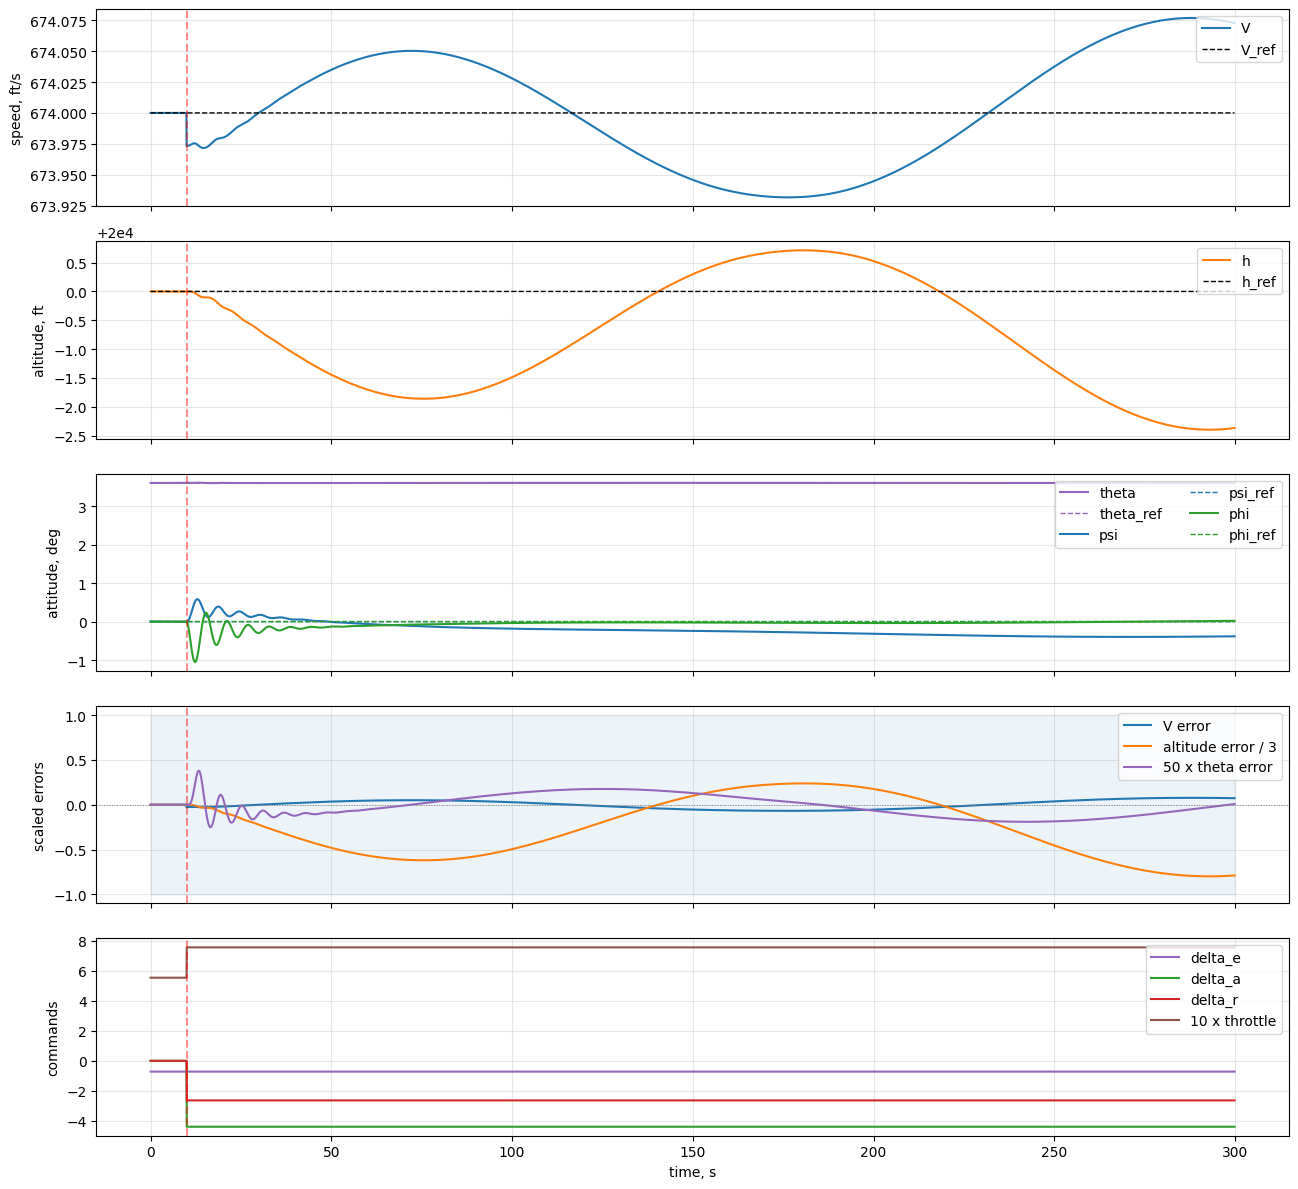

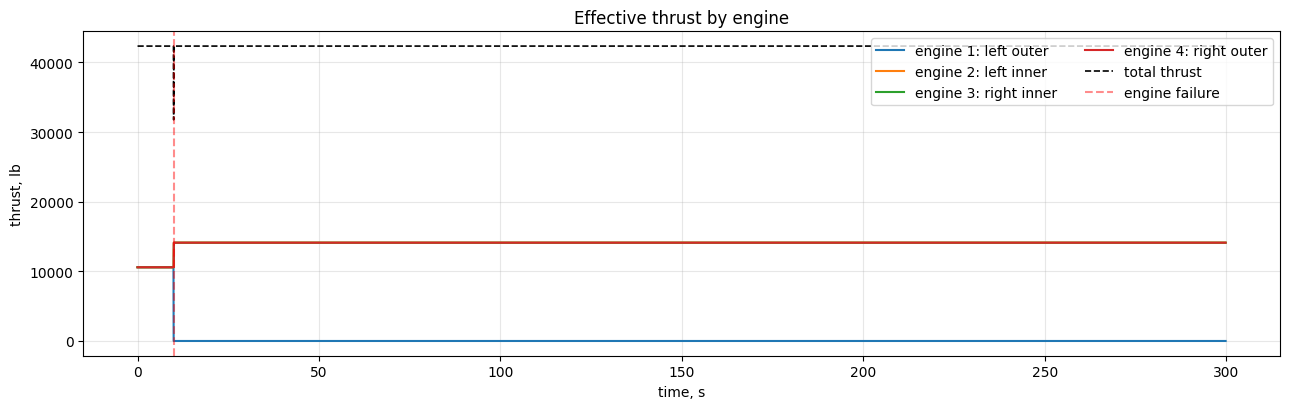

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)

axes[0].plot(log["t"], log["V_actual"], color="tab:blue", label="V")
axes[0].plot(log["t"], log["V_ref"], color="black", linestyle="--", linewidth=1.0,
             label="V_ref")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[0].set_ylabel("speed, ft/s")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

axes[1].plot(log["t"], log["h_actual"], color="tab:orange", label="h")
axes[1].plot(log["t"], log["h_ref"], color="black", linestyle="--", linewidth=1.0,
             label="h_ref")
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].set_ylabel("altitude, ft")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

axes[2].plot(log["t"], log["theta_actual"], color="tab:purple", label="theta")
axes[2].plot(log["t"], log["theta_ref"], color="tab:purple", linestyle="--", linewidth=1.0,
             label="theta_ref")
axes[2].plot(log["t"], log["psi_actual"], color="tab:blue", label="psi")
axes[2].plot(log["t"], log["psi_ref"], color="tab:blue", linestyle="--", linewidth=1.0,
             label="psi_ref")
axes[2].plot(log["t"], log["phi_actual"], color="tab:green", label="phi")
axes[2].plot(log["t"], log["phi_ref"], color="tab:green", linestyle="--", linewidth=1.0,
             label="phi_ref")
axes[2].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[2].set_ylabel("attitude, deg")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="upper right", ncol=2)

axes[3].fill_between(log["t"], -SPEED_HOLD_BAND_FT_S, SPEED_HOLD_BAND_FT_S,
                     color="tab:blue", alpha=0.08)
axes[3].plot(log["t"], log["V"], color="tab:blue", label="V error")
axes[3].plot(log["t"], log["h"] / 3.0, color="tab:orange", label="altitude error / 3")
axes[3].plot(log["t"], 50.0 * log["theta"], color="tab:purple", label="50 x theta error")
axes[3].axhline(0.0, color="tab:gray", linestyle=":", linewidth=0.7)
axes[3].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[3].set_ylabel("scaled errors")
axes[3].grid(True, alpha=0.3)
axes[3].legend(loc="upper right")

axes[4].plot(log["t"], log["de"], color="tab:purple", label="delta_e")
axes[4].plot(log["t"], log["da"], color="tab:green", label="delta_a")
axes[4].plot(log["t"], log["dr"], color="tab:red", label="delta_r")
axes[4].plot(log["t"], 10.0 * log["throttle"], color="tab:brown",
             label="10 x throttle")
axes[4].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[4].set_xlabel("time, s")
axes[4].set_ylabel("commands")
axes[4].grid(True, alpha=0.3)
axes[4].legend(loc="upper right")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(13, 4.2))
engine_labels = {
    "T1": "engine 1: left outer",
    "T2": "engine 2: left inner",
    "T3": "engine 3: right inner",
    "T4": "engine 4: right outer",
}
for key, label in engine_labels.items():
    ax.plot(log["t"], log[key], label=label)
ax.plot(log["t"], log["T_total"], color="black", linewidth=1.2,
        linestyle="--", label="total thrust")
ax.axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
           label="engine failure")
ax.set_title("Effective thrust by engine")
ax.set_xlabel("time, s")
ax.set_ylabel("thrust, lb")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()


## 9. Comparison: open loop vs. full ET-DHP

Open loop means healthy-trim elevator, zero aileron/rudder and healthy-trim throttle throughout the same engine-failure scenario. This comparison shows the effect of the full ET-DHP stack across all four control channels.


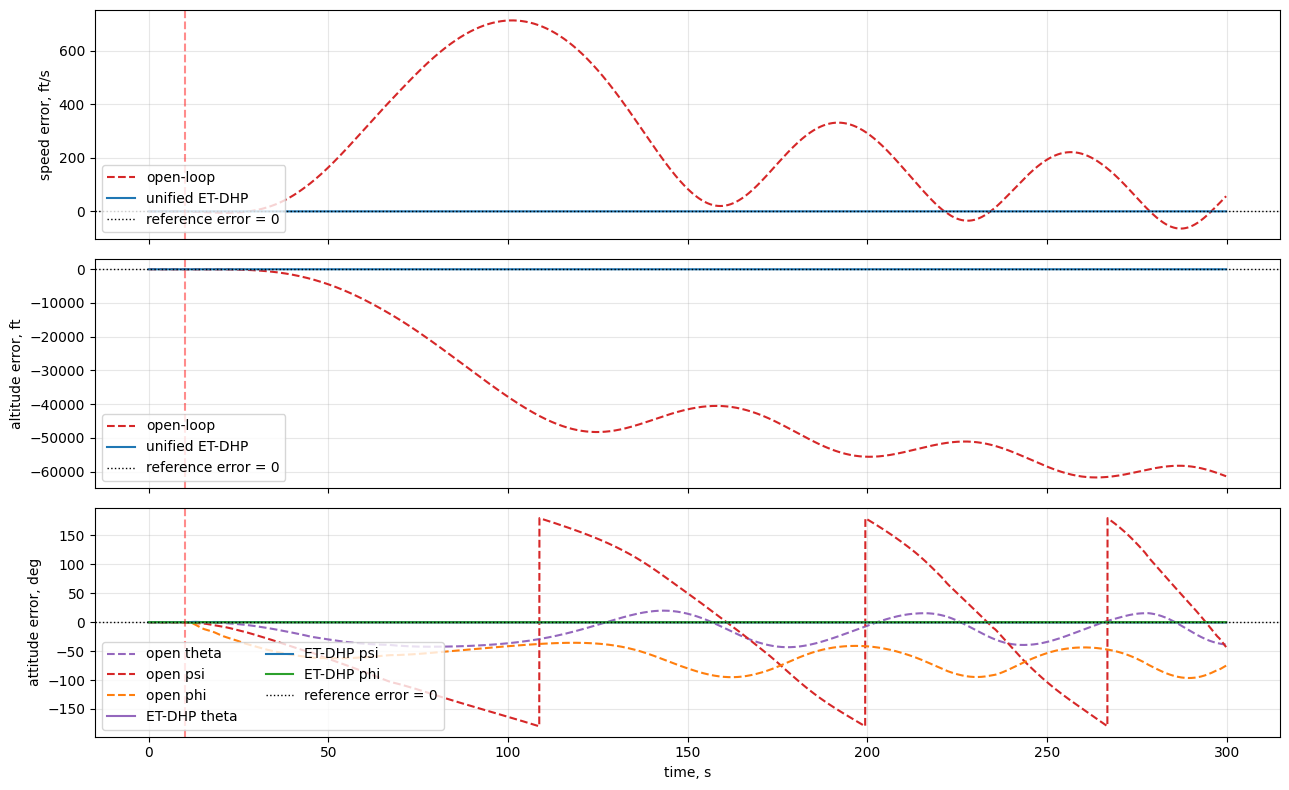

Open-loop @ t=300s: Verr=+56.56 ft/s, herr=-61392.1 ft, theta=-38.36 deg, psi=-43.04 deg, phi=-75.06 deg
Unified ET-DHP @ t=300s: Verr=+0.07 ft/s, herr=-2.4 ft, theta=+0.000 deg, psi=-0.383 deg, phi=+0.020 deg


In [9]:
def run_open_loop(damage_profile):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    logs = {name: np.zeros(N_EP) for name in ["V", "h", "theta", "psi", "phi"]}
    neutral_action = compose_action([0.0, 0.0, 0.0, 0.0])
    for k in range(N_EP - 2):
        obs, _, _, trunc, _ = env.step(neutral_action)
        logs["V"][k] = true_airspeed_ft_s(obs) - V_REF_FT_S
        logs["h"][k] = altitude_ft(obs) - ALT_REF_FT
        logs["theta"][k] = pitch_error_deg(obs)
        logs["psi"][k] = yaw_error_deg(obs)
        logs["phi"][k] = roll_deg(obs)
        if trunc:
            break
    n = k + 1
    result = {name: values[:n] for name, values in logs.items()}
    result["t"] = np.arange(n) * DT
    return result


open_log = run_open_loop(LEFT_OUTER_ENGINE_FAILURE)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(open_log["t"], open_log["V"], color="tab:red", linestyle="--", label="open-loop")
axes[0].plot(log["t"], log["V"], color="tab:blue", label="unified ET-DHP")
axes[0].axhline(0.0, color="black", linestyle=":", linewidth=1.0, label="reference error = 0")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[0].set_ylabel("speed error, ft/s")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="lower left")

axes[1].plot(open_log["t"], open_log["h"], color="tab:red", linestyle="--", label="open-loop")
axes[1].plot(log["t"], log["h"], color="tab:blue", label="unified ET-DHP")
axes[1].axhline(0.0, color="black", linestyle=":", linewidth=1.0, label="reference error = 0")
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].set_ylabel("altitude error, ft")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="lower left")

axes[2].plot(open_log["t"], open_log["theta"], color="tab:purple", linestyle="--", label="open theta")
axes[2].plot(open_log["t"], open_log["psi"], color="tab:red", linestyle="--", label="open psi")
axes[2].plot(open_log["t"], open_log["phi"], color="tab:orange", linestyle="--", label="open phi")
axes[2].plot(log["t"], log["theta"], color="tab:purple", label="ET-DHP theta")
axes[2].plot(log["t"], log["psi"], color="tab:blue", label="ET-DHP psi")
axes[2].plot(log["t"], log["phi"], color="tab:green", label="ET-DHP phi")
axes[2].axhline(0.0, color="black", linestyle=":", linewidth=1.0, label="reference error = 0")
axes[2].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[2].set_xlabel("time, s")
axes[2].set_ylabel("attitude error, deg")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="lower left", ncol=2)

plt.tight_layout()
plt.show()

print(f"Open-loop @ t={TOTAL_TIME:.0f}s: Verr={open_log['V'][-1]:+.2f} ft/s, "
      f"herr={open_log['h'][-1]:+.1f} ft, theta={open_log['theta'][-1]:+.2f} deg, "
      f"psi={open_log['psi'][-1]:+.2f} deg, phi={open_log['phi'][-1]:+.2f} deg")
print(f"Unified ET-DHP @ t={TOTAL_TIME:.0f}s: Verr={log['V'][-1]:+.2f} ft/s, "
      f"herr={log['h'][-1]:+.1f} ft, theta={log['theta'][-1]:+.3f} deg, "
      f"psi={log['psi'][-1]:+.3f} deg, phi={log['phi'][-1]:+.3f} deg")


The controller above is a single online ET-DHP actor with four outputs
`[elevator, aileron, rudder, throttle]`. The plant model is identified from
persistent-excitation transitions, then runtime control is
`actor.predict -> env.step -> agent.learn`.

There is no PID loop, no Riccati/LQR actor distillation, and no DAgger dataset.
The DHP part is inside `agent.learn`: the critic estimates the costate
`lambda(x) = dJ/dx`, the plant model supplies the local Jacobians, and the
actor is updated toward the ET-DHP saturated optimal-control target. Adam is
used only as the optimizer for these ET-DHP losses; it is not a teacher policy.

The `engine_loss` feature is used because the no-bias ET-DHP actor must still
produce a nonzero asymmetric trim command when one engine is lost. Feedback
around that trim is learned online by ET-DHP. The reported last-window slopes
are the main trend check: they should be close to zero rather than persistently
positive or negative.
